In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries loaded successfully!")

libraries loaded successfully!


In [3]:
import pandas as pd
df=pd.read_csv("../data/raw/air_quality_pm25_2023.csv")
df.head()

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024
1,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024
2,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024
3,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024
4,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024


In [4]:
df.shape

(847370, 29)

In [5]:
df.columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type',
       'Observation Count', 'Observation Percent', 'Arithmetic Mean',
       '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name',
       'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name',
       'CBSA Name', 'Date of Last Change'],
      dtype='str')

In [6]:
chicago_df = df[df["City Name"] == "Chicago"]

chicago_df.shape

(359, 29)

In [7]:
chicago_df = chicago_df[[
    "Date Local",
    "Arithmetic Mean",
    "AQI",
    "Latitude",
    "Longitude"
]]

chicago_df.head()

,Date Local,Arithmetic Mean,AQI,Latitude,Longitude
230380,1/3/2023,6.9,38.0,41.687165,-87.539315
230381,1/6/2023,11.2,55.0,41.687165,-87.539315
230382,1/9/2023,20.0,71.0,41.687165,-87.539315
230383,1/12/2023,11.3,55.0,41.687165,-87.539315
230384,1/15/2023,7.8,43.0,41.687165,-87.539315


In [8]:
chicago_df["Date Local"] = pd.to_datetime(chicago_df["Date Local"])

chicago_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 359 entries, 230380 to 230738
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date Local       359 non-null    datetime64[us]
 1   Arithmetic Mean  359 non-null    float64       
 2   AQI              359 non-null    float64       
 3   Latitude         359 non-null    float64       
 4   Longitude        359 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 14.2 KB


In [9]:
chicago_df = chicago_df.sort_values("Date Local")

chicago_df.head()

,Date Local,Arithmetic Mean,AQI,Latitude,Longitude
230380,2023-01-03,6.9,38.0,41.687165,-87.539315
230501,2023-01-03,6.5,36.0,41.965485,-87.749928
230381,2023-01-06,11.2,55.0,41.687165,-87.539315
230502,2023-01-06,8.2,46.0,41.965485,-87.749928
230619,2023-01-06,8.6,48.0,41.912739,-87.722673


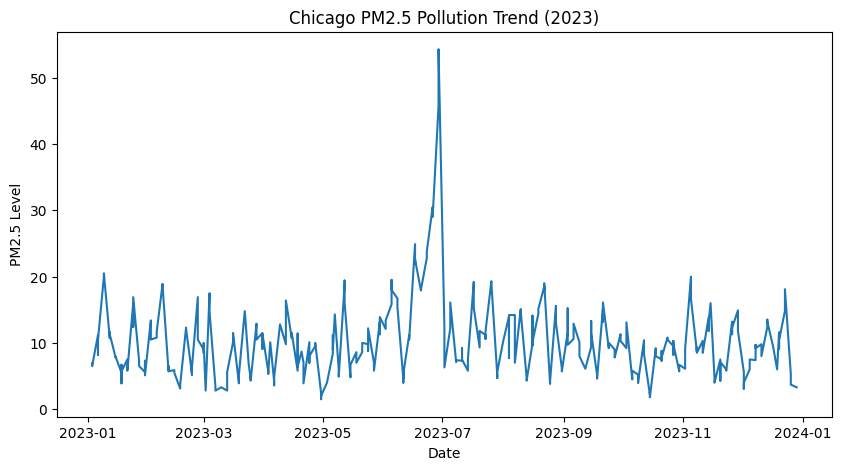

In [10]:
plt.figure(figsize=(10,5))

plt.plot(chicago_df["Date Local"], chicago_df["Arithmetic Mean"])

plt.title("Chicago PM2.5 Pollution Trend (2023)")
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")

plt.show()

In [11]:
chicago_df["PM25_MA7"] = chicago_df["Arithmetic Mean"].rolling(window=7).mean()

chicago_df.head()

,Date Local,Arithmetic Mean,AQI,Latitude,Longitude,PM25_MA7
230380,2023-01-03,6.9,38.0,41.687165,-87.539315,NaN
230501,2023-01-03,6.5,36.0,41.965485,-87.749928,NaN
230381,2023-01-06,11.2,55.0,41.687165,-87.539315,NaN
230502,2023-01-06,8.2,46.0,41.965485,-87.749928,NaN
230619,2023-01-06,8.6,48.0,41.912739,-87.722673,NaN


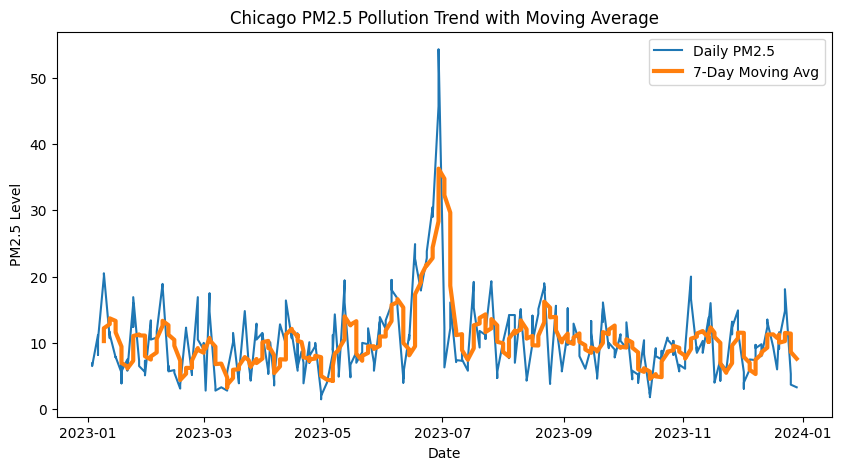

In [12]:
plt.figure(figsize=(10,5))

plt.plot(chicago_df["Date Local"], chicago_df["Arithmetic Mean"], label="Daily PM2.5")
plt.plot(chicago_df["Date Local"], chicago_df["PM25_MA7"], label="7-Day Moving Avg", linewidth=3)

plt.title("Chicago PM2.5 Pollution Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")

plt.legend()
plt.show()

In [13]:
chicago_df["Month"] = chicago_df["Date Local"].dt.month

monthly_pollution = chicago_df.groupby("Month")["Arithmetic Mean"].mean().reset_index()

monthly_pollution

,Month,Arithmetic Mean
0,1,9.513333
1,2,8.996000
2,3,7.327273
3,4,7.667742
4,5,10.226667
5,6,20.706897
6,7,10.963333
7,8,11.903125
8,9,10.333333
9,10,7.376667


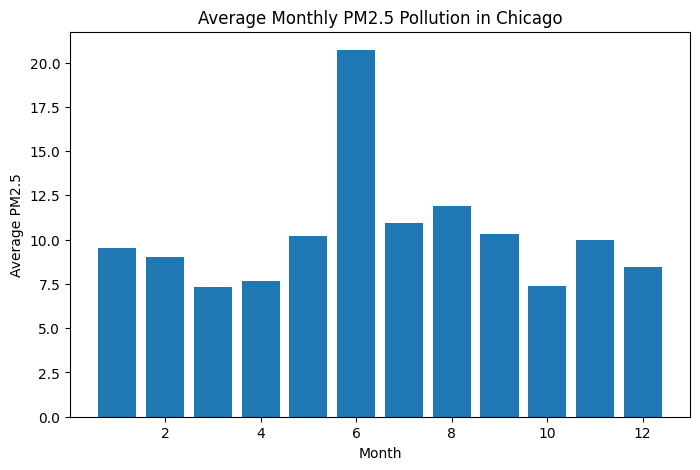

In [14]:
plt.figure(figsize=(8,5))

plt.bar(monthly_pollution["Month"], monthly_pollution["Arithmetic Mean"])

plt.title("Average Monthly PM2.5 Pollution in Chicago")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.show()

In [15]:
cta_df = pd.read_csv("../data/raw/CTA_-_Ridership_-_Daily_Boarding_Totals_20260411.csv")

cta_df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,01/01/2001,U,"297,192","126,455","423,647"
1,01/02/2001,W,"780,827","501,952","1,282,779"
2,01/03/2001,W,"824,923","536,432","1,361,355"
3,01/04/2001,W,"870,021","550,011","1,420,032"
4,01/05/2001,W,"890,426","557,917","1,448,343"


In [16]:
cta_df["service_date"] = pd.to_datetime(cta_df["service_date"])

In [17]:
cta_df["Month"] = cta_df["service_date"].dt.month

In [18]:
cta_df["total_rides"] = cta_df["total_rides"].str.replace(",", "", regex=False)
cta_df["total_rides"] = pd.to_numeric(cta_df["total_rides"])

In [19]:
monthly_ridership = cta_df.groupby("Month")["total_rides"].mean().reset_index()

monthly_ridership

,Month,total_rides
0,1,1.104965e+06
1,2,1.209454e+06
2,3,1.217720e+06
3,4,1.212221e+06
4,5,1.220474e+06
5,6,1.238764e+06
6,7,1.201493e+06
7,8,1.219927e+06
8,9,1.298775e+06
9,10,1.318776e+06


In [20]:
combined_df = pd.merge(monthly_pollution, monthly_ridership, on="Month")

combined_df

,Month,Arithmetic Mean,total_rides
0,1,9.513333,1.104965e+06
1,2,8.996000,1.209454e+06
2,3,7.327273,1.217720e+06
3,4,7.667742,1.212221e+06
4,5,10.226667,1.220474e+06
5,6,20.706897,1.238764e+06
6,7,10.963333,1.201493e+06
7,8,11.903125,1.219927e+06
8,9,10.333333,1.298775e+06
9,10,7.376667,1.318776e+06


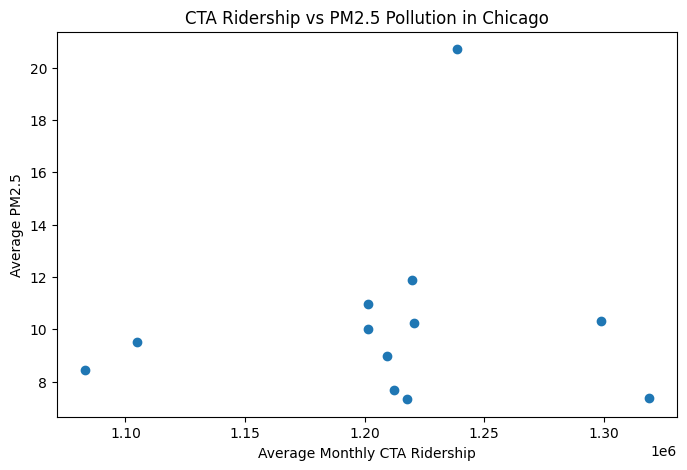

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(combined_df["total_rides"], combined_df["Arithmetic Mean"])

plt.title("CTA Ridership vs PM2.5 Pollution in Chicago")
plt.xlabel("Average Monthly CTA Ridership")
plt.ylabel("Average PM2.5")

plt.show()

In [22]:
combined_df[["total_rides","Arithmetic Mean"]].corr()

,total_rides,Arithmetic Mean
total_rides,1.00000,0.11061
Arithmetic Mean,0.11061,1.00000


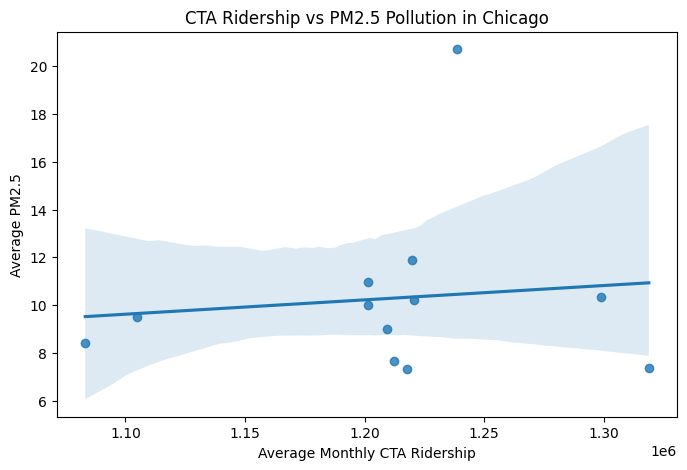

In [23]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    x="total_rides",
    y="Arithmetic Mean",
    data=combined_df
)

plt.title("CTA Ridership vs PM2.5 Pollution in Chicago")
plt.xlabel("Average Monthly CTA Ridership")
plt.ylabel("Average PM2.5")

plt.show()

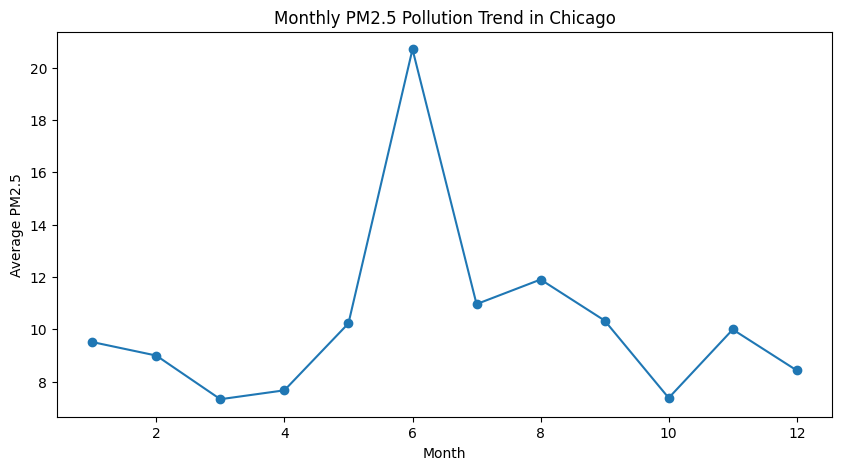

In [24]:
plt.figure(figsize=(10,5))

plt.plot(combined_df["Month"], combined_df["Arithmetic Mean"], marker="o")

plt.title("Monthly PM2.5 Pollution Trend in Chicago")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.show()

In [25]:
combined_df.to_csv("../data/processed/combined_air_quality_transit.csv", index=False)

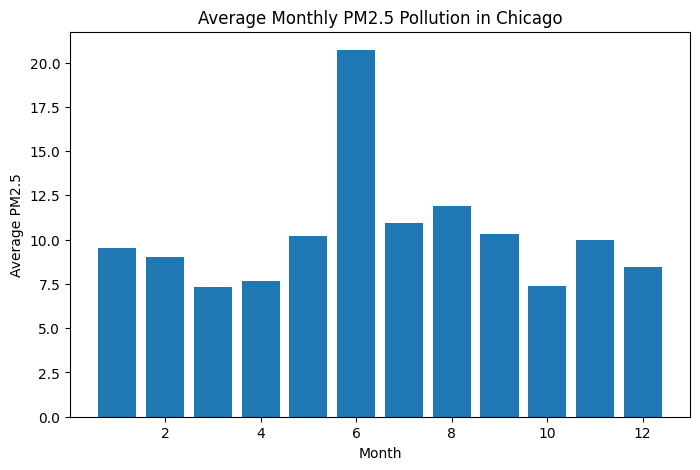

In [26]:
plt.figure(figsize=(8,5))

plt.bar(monthly_pollution["Month"], monthly_pollution["Arithmetic Mean"])

plt.title("Average Monthly PM2.5 Pollution in Chicago")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.savefig("../outputs/monthly_pollution_chart.png")

plt.show()

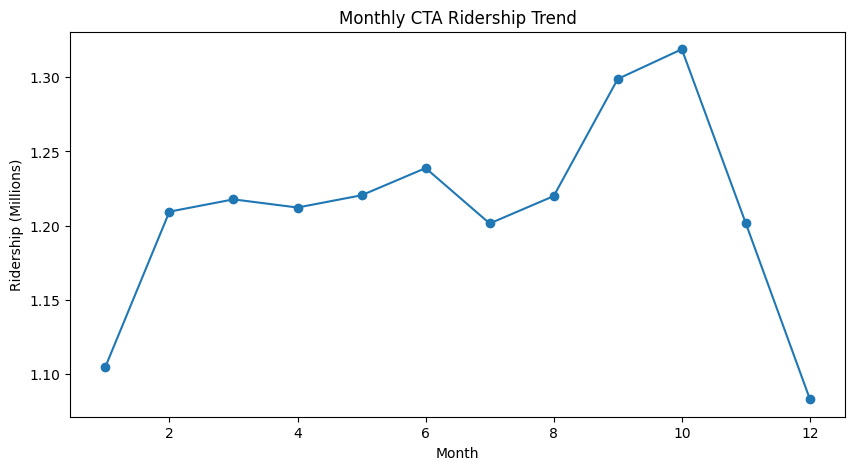

In [27]:
plt.figure(figsize=(10,5))

plt.plot(combined_df["Month"], combined_df["total_rides"]/1000000, marker="o")

plt.title("Monthly CTA Ridership Trend")
plt.xlabel("Month")
plt.ylabel("Ridership (Millions)")

plt.savefig("../outputs/ridership_trend.png")

plt.show()

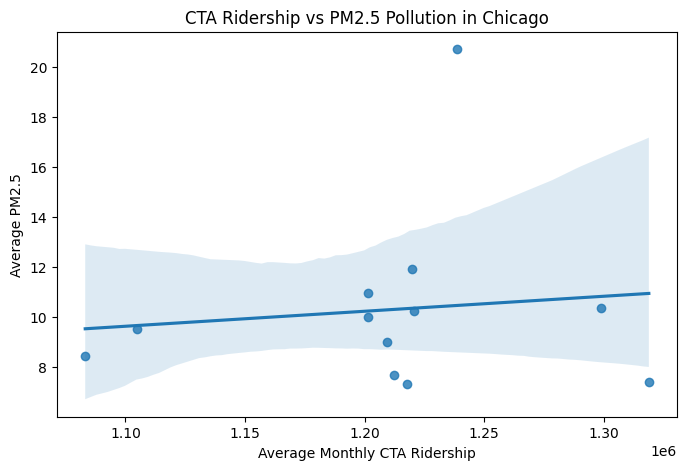

In [28]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="total_rides",
    y="Arithmetic Mean",
    data=combined_df
)

plt.title("CTA Ridership vs PM2.5 Pollution in Chicago")
plt.xlabel("Average Monthly CTA Ridership")
plt.ylabel("Average PM2.5")

plt.savefig("../outputs/ridership_vs_pollution.png")

plt.show()